# Taking Attention from an Expression to PyTorch

One block of multi-head attention is written as an expression, its free axis
sizes are collected and assigned, the sized expression is compiled to a PyTorch
module and its output is compared against a module written by hand. The same
expression is then converted to a hypergraph and back, which is the form every
rewrite in the package works in.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Operators as ops
import display.display_config as display_config
import einops
import graphs.data_structure.Hypergraph as hg
import graphs.processing.Hypergraph2Morphism as h2m
import term_utilities.generate_config as generate_config
import torch
import torch_compile.torch_compile as torch_compile
from torch_compile.torch_utilities import Multilinear

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=800)

## Aligning the axes automatically

`@` composes two morphisms and aligns the codomain of the left one against the
domain of the right one by position. The four operators below are written one
after another and nothing states which axis of the scores the softmax consumes
or which axis of the values the second contraction sums over. Alignment
supplies both.

Scaled dot-product attention over several heads.


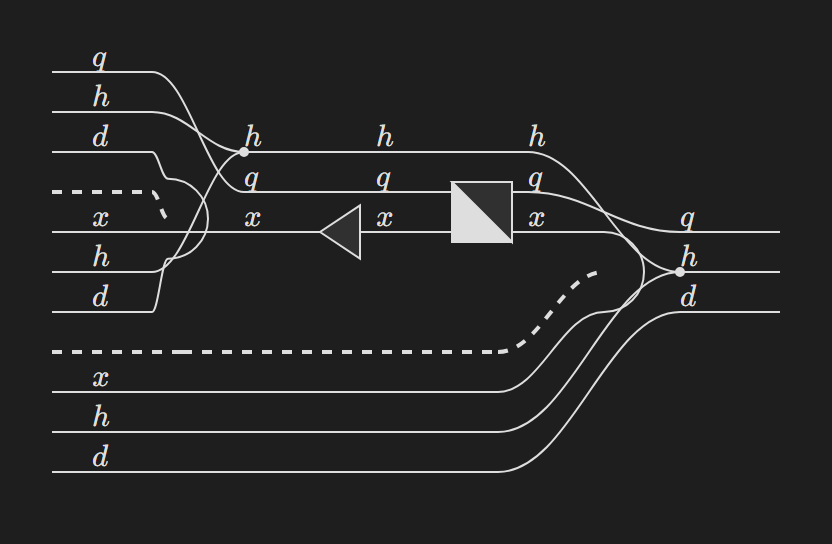

In [2]:
attention_core = (ops.Einops.template('q h d, x h d -> h q x')
                  @ ops.SoftMax.template()
                  @ ops.WeightedTriangularLower.template()
                  @ ops.Einops.template('h q x, x h d -> q h d'))

assert len(attention_core.dom()) == 3, (
    'the core reads the queries, the keys and the values')
assert [len(array.shape()) for array in attention_core.dom()] == [3, 3, 3], (
    'each operand carries the tokens, the heads and the head dimension')
await notebook_diagrams.show_diagram(
    attention_core,
    'Scaled dot-product attention over several heads.',
    settings=DIAGRAMS)

## The projections and the residual

`(0, 0)` and `(0, 0, 0)` are rearrangements written as index tuples. The tuple
gives, for each outgoing wire, the incoming wire it comes from, so `(0, 0)`
copies one wire in two and `(0, 0, 0)` copies it in three. The copy in front of
the projections feeds the query, the key and the value from one input, and the
copy around the whole block is the residual.

Multi-head attention with its projections and its residual.


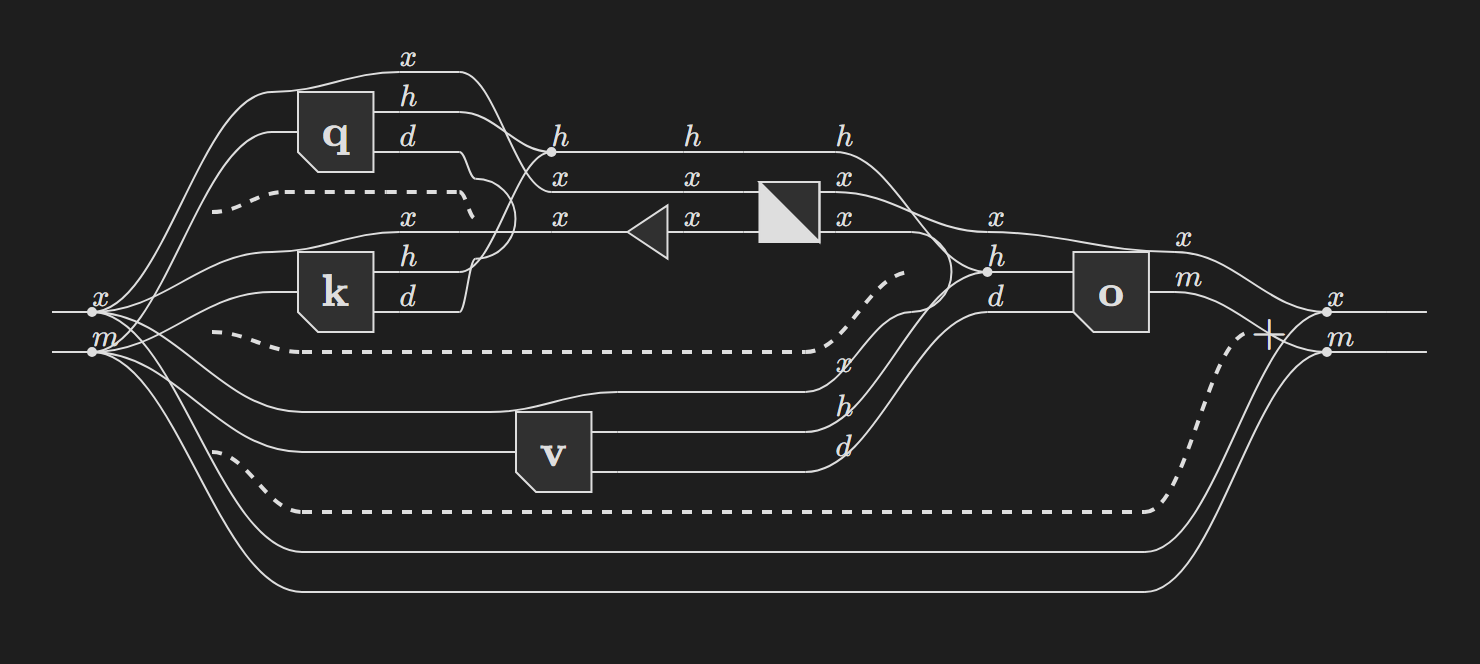

In [3]:
def residual[B: cat.Datatype, A: cat.Axis](
    target: cat.BroadcastedCategory[B, A],
) -> cat.BroadcastedCategory[B, A]:
    return (0, 0) @ target @ ops.AdditionOp.template()


query, key, value = [ops.Linear.template('m', 2, name) for name in ['q', 'k', 'v']]
output = ops.Linear.template(2, 'm', 'o')
attention_linears = (0, 0, 0) @ (query * key * value) @ attention_core @ output
attention_block = residual(attention_linears)

assert attention_block.dom() == attention_block.cod(), (
    'the residual block returns the object it was given')
await notebook_diagrams.show_diagram(
    attention_block,
    'Multi-head attention with its projections and its residual.',
    settings=DIAGRAMS)

## Applying the configuration

`NumericConfig.template` scans the expression for free symbols and
`assign_values` puts each name it is given in a bucket with an integer.
`apply_context` rewrites the expression with those integers in place of the
symbols, so a configuration taken of the result finds only the sequence length
and the epsilon of the normalisation still free.

Scanning for free numerics,
Name|Type       |Bucket  |Assignment
x   |FreeNumeric|        |          
m   |FreeNumeric|        |          
h   |FreeNumeric|        |          
d   |FreeNumeric|        |          
d   |FreeNumeric|        |          

Applying the configuration,
Name|Type       |Bucket  |Assignment          
x   |FreeNumeric|        |                    
m   |FreeNumeric|2       |Integer(_value=1024)
h   |FreeNumeric|1       |Integer(_value=8)   
d   |FreeNumeric|0       |Integer(_value=128) 
d   |FreeNumeric|0       |Integer(_value=128) 
The sized block. Each wire carries the integer its axis was given.


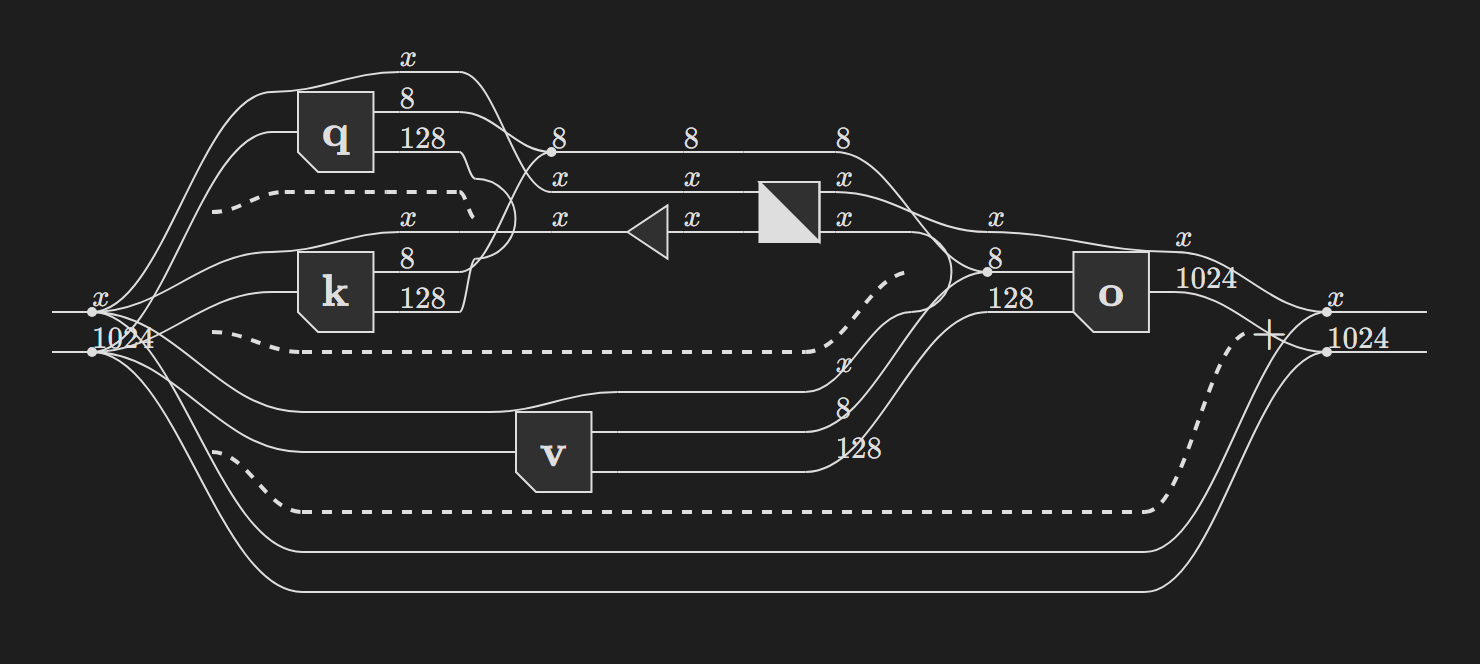

In [4]:
config = generate_config.NumericConfig.template(attention_block)
print('Scanning for free numerics,')
print(display_config.display_config(config))

ATTENTION_INNER, ATTENTION_HEADS, MODEL_DIMENSION = (128, 8, 1024)
config.assign_values(
    d=ATTENTION_INNER, h=ATTENTION_HEADS, m=MODEL_DIMENSION)
print('\nApplying the configuration,')
print(display_config.display_config(config))
configured_attention = config.apply_context(attention_block)

remaining = generate_config.NumericConfig.template(configured_attention)
assert {term.uid._name.to_bodies() for term in remaining.terms} == {'x'}, (
    'the sequence length is the one symbol that stays free')
await notebook_diagrams.show_diagram(
    configured_attention,
    'The sized block. Each wire carries the integer its axis was given.',
    settings=DIAGRAMS)

## Compiling to PyTorch and checking the result

`ConstructedModule.construct` builds an `nn.Module` from the sized expression.
The module below is the same architecture written by hand with `einops`. The
parameters of the constructed module are copied into the handwritten one, both
are run on the same input, and the two outputs are compared exactly.

`torch` and `einops` are what this section needs, and neither is listed in
`requirements.txt`.

In [5]:
def weighted_triangular_lower(x: torch.Tensor) -> torch.Tensor:
    trilled = torch.tril(x)
    return trilled / (torch.sum(trilled, dim=-1, keepdim=True) + 1e-8)


class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d: int, h: int, m: int):
        super().__init__()
        self.d, self.h, self.m = d, h, m
        self.query, self.key, self.value = [
            Multilinear(m, (h, d), bias=False) for _ in range(3)]
        self.output = Multilinear((h, d), m, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        q, k, v = (self.query(x), self.key(x), self.value(x))
        scores = einops.einsum(q, k, '... q h d, ... x h d -> ... h q x')
        scores = torch.softmax(scores, dim=-1)
        scores = weighted_triangular_lower(scores)
        weighted = einops.einsum(scores, v, '... h q x, ... x h d -> ... q h d')
        return self.output(weighted) + x


handwritten = MultiHeadAttention(
    ATTENTION_INNER, ATTENTION_HEADS, MODEL_DIMENSION)
constructed = torch_compile.ConstructedModule.construct(configured_attention)

with torch.inference_mode():
    for reference, derived in zip(
            handwritten.parameters(), constructed.parameters()):
        reference.data = derived.data.clone()

    BATCH_SIZE, SEQUENCE_LENGTH = 8, 16
    tokens = torch.randn(BATCH_SIZE, SEQUENCE_LENGTH, MODEL_DIMENSION)
    from_expression, = constructed(tokens)
    from_reference = handwritten(tokens)

assert torch.equal(from_expression, from_reference), (
    'the compiled expression and the handwritten module return the same tensor')
print(f'{tuple(from_expression.shape)} out of both modules, equal elementwise')

(8, 16, 1024) out of both modules, equal elementwise


## Converting to a hypergraph and back

A morphism is the form an expression is read in and a hypergraph is the form it
is rewritten in. `Multigraph.from_morphism` converts one way and
`hypergraph_to_morphism` the other. The conversion normalises the expression,
so converting the result a second time returns it unchanged.

The expression rebuilt from its hypergraph.


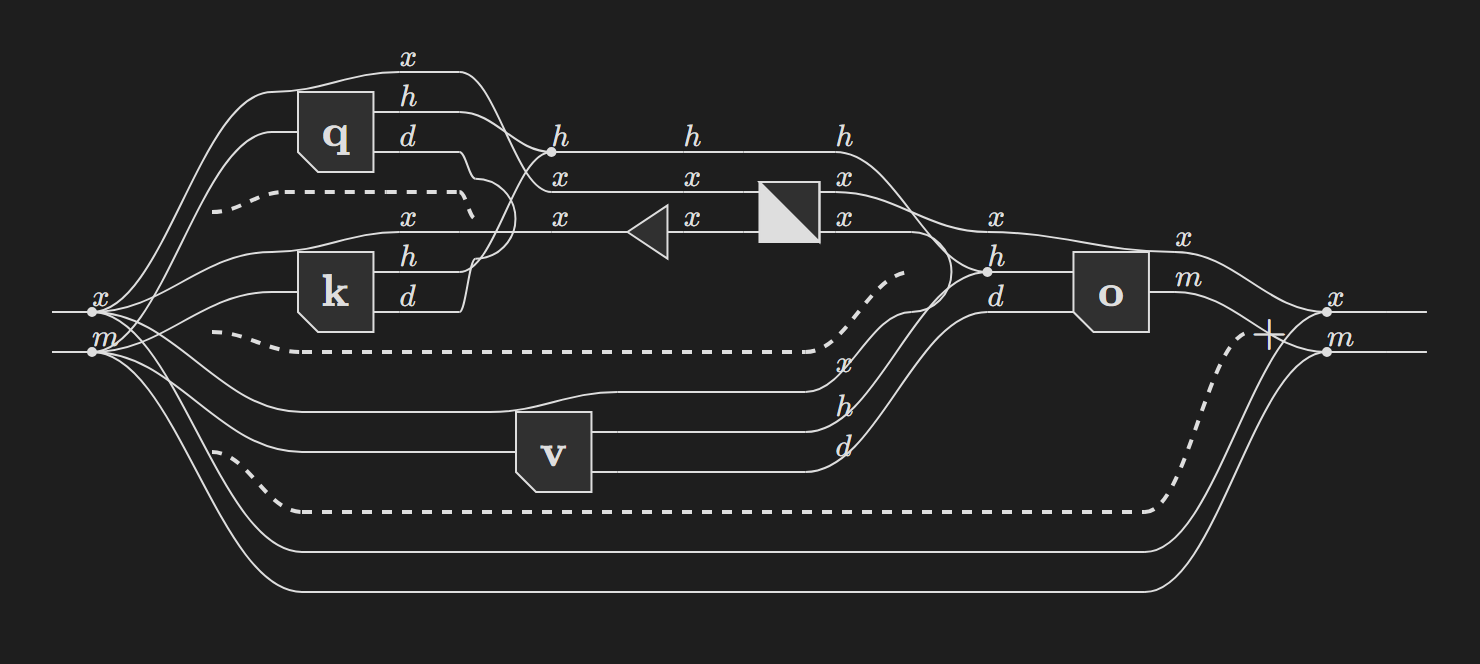

In [6]:
graph = hg.Multigraph.from_morphism(attention_block)
reconstructed = h2m.hypergraph_to_morphism(graph)

assert reconstructed.dom() == attention_block.dom(), (
    'the reconstruction reads what the expression read')
assert reconstructed.cod() == attention_block.cod(), (
    'the reconstruction writes what the expression wrote')
assert h2m.recycle(reconstructed) == reconstructed, (
    'a second conversion leaves the normalised expression unchanged')
await notebook_diagrams.show_diagram(
    reconstructed,
    'The expression rebuilt from its hypergraph.',
    settings=DIAGRAMS)